In [1]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
#LOAD DATASET

#CHOOSE THE CSV FILE TO UPLOAD AND RUN IT

from google.colab import files

uploaded = files.upload()

Saving instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv to instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv (5).csv


In [3]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
#UNDERSTAND THE DATASET

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (2000, 12)

Columns:
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Data types:
batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object

First 5 rows:


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [5]:
#DATASET INFORMATION

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [6]:
#UNIQUE VALUES

print("Number of instructors:", df["instructor_id"].nunique())
print("Number of courses:", df["course_id"].nunique())
print("Number of batches:", df["batch_id"].nunique())

Number of instructors: 120
Number of courses: 25
Number of batches: 2000


In [7]:
#CHECKING FOR MISSING VALUES

missing_values = df.isnull().sum()

print(missing_values)

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

display(missing_table)

,Missing Values,Percentage
batch_id,0,0.0
instructor_id,0,0.0
course_id,0,0.0
completion_rate,0,0.0
avg_score_improvement,0,0.0
avg_quiz_score,0,0.0
dropout_rate,0,0.0
avg_watch_time,0,0.0
assignment_submission_rate,0,0.0
forum_activity_rate,0,0.0


In [9]:
#CHECK FOR DUPLICATE VALUES

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate batch IDs:", df["batch_id"].duplicated().sum())

Duplicate rows: 0
Duplicate batch IDs: 0


In [10]:
#CHECK FOR ANAMOLIES

numeric_columns = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

for column in numeric_columns:
    print(
        column,
        "-> Min:", round(df[column].min(), 3),
        "| Max:", round(df[column].max(), 3)
    )

completion_rate -> Min: 0.3 | Max: 0.98
avg_score_improvement -> Min: 6.159 | Max: 40.0
avg_quiz_score -> Min: 40.387 | Max: 100.0
dropout_rate -> Min: 0.02 | Max: 0.7
avg_watch_time -> Min: 0.287 | Max: 1.0
assignment_submission_rate -> Min: 0.251 | Max: 1.0
forum_activity_rate -> Min: 0.0 | Max: 0.641
avg_feedback_score -> Min: 2.64 | Max: 5.0
feedback_response_rate -> Min: 0.26 | Max: 1.0


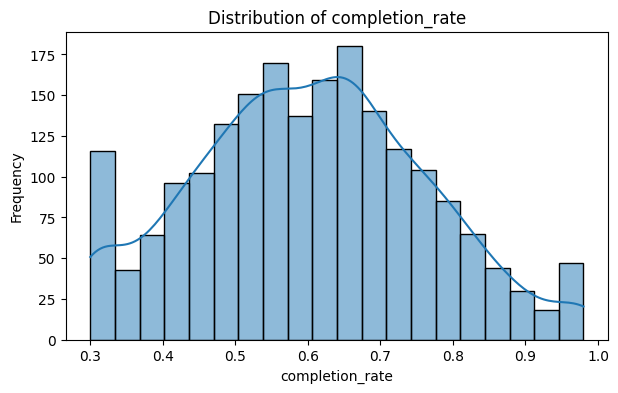

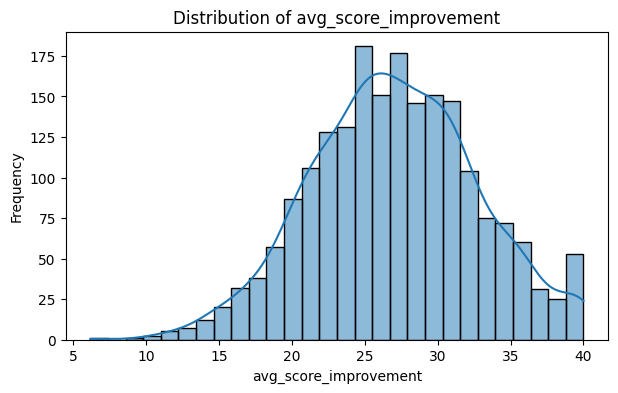

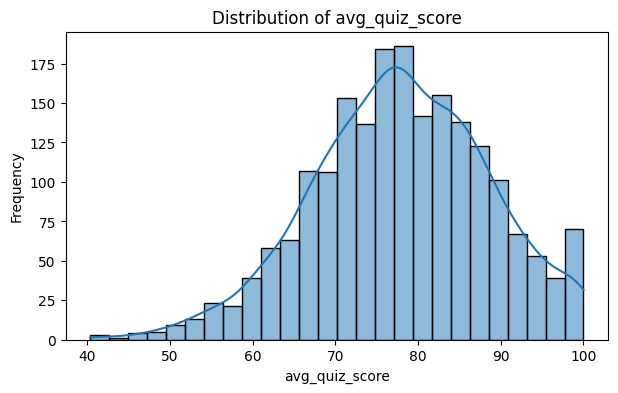

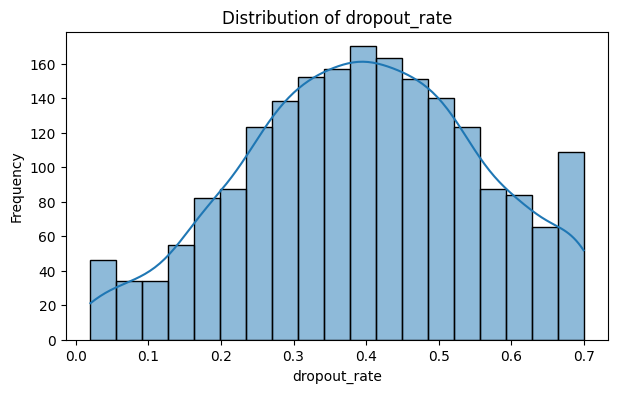

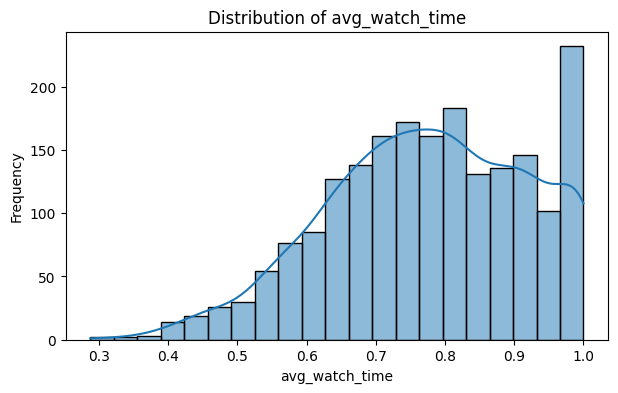

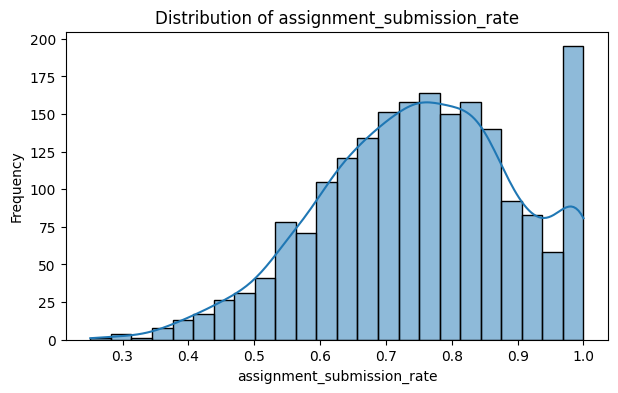

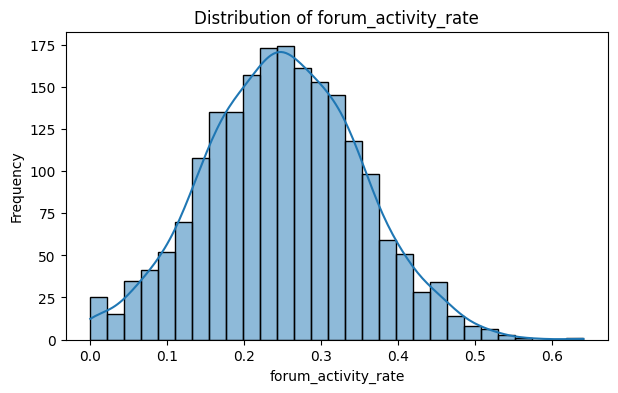

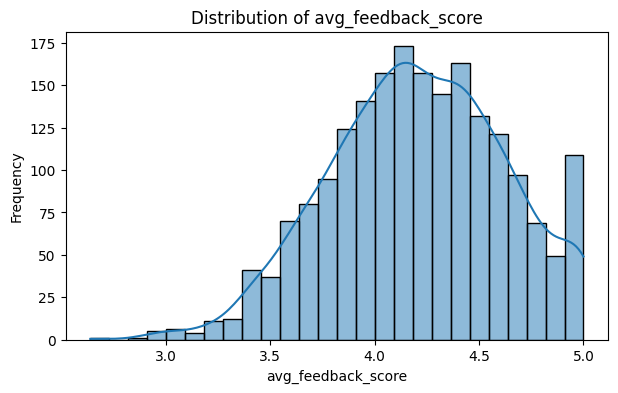

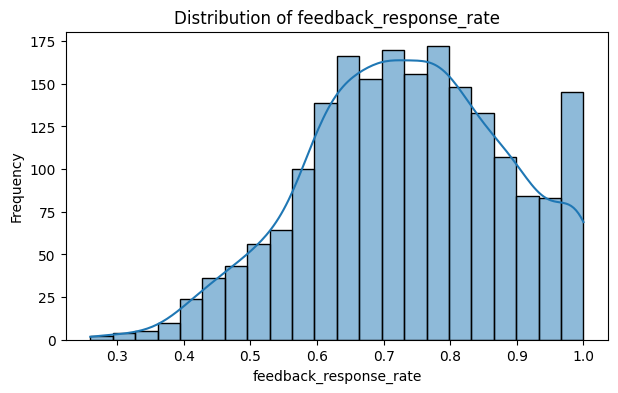

In [11]:
# DISTRIBUTION OF NUMERIC VARIABLES

for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

In [12]:
# OUTLIER CHECK USING IQR

print("Potential outliers:\n")

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} potential outliers")

Potential outliers:

completion_rate: 0 potential outliers
avg_score_improvement: 6 potential outliers
avg_quiz_score: 11 potential outliers
dropout_rate: 0 potential outliers
avg_watch_time: 3 potential outliers
assignment_submission_rate: 6 potential outliers
forum_activity_rate: 5 potential outliers
avg_feedback_score: 11 potential outliers
feedback_response_rate: 5 potential outliers


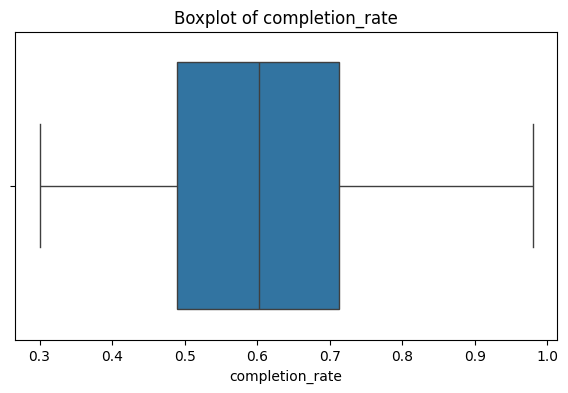

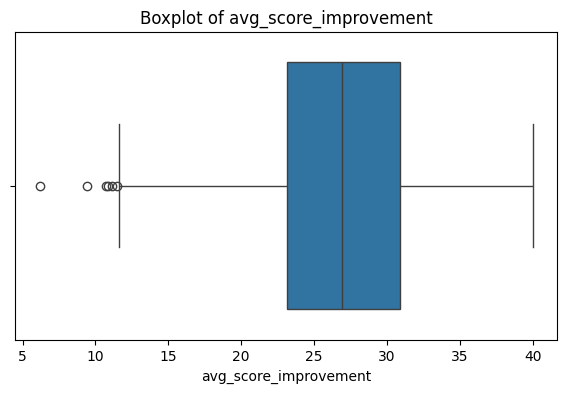

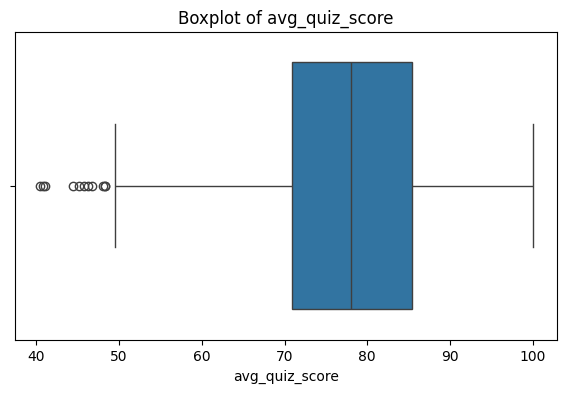

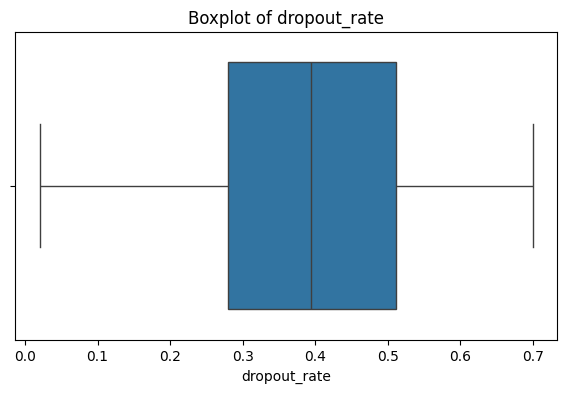

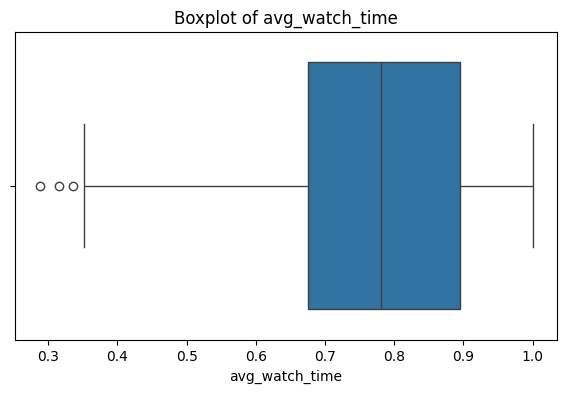

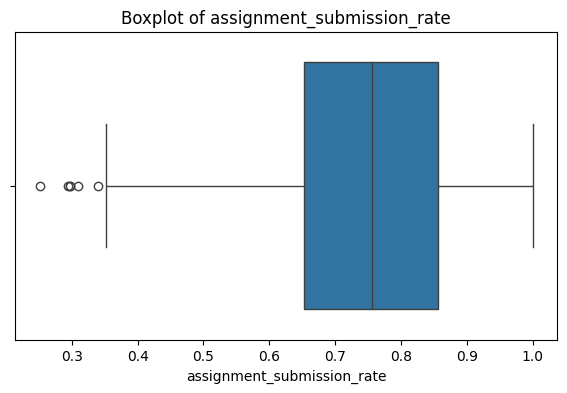

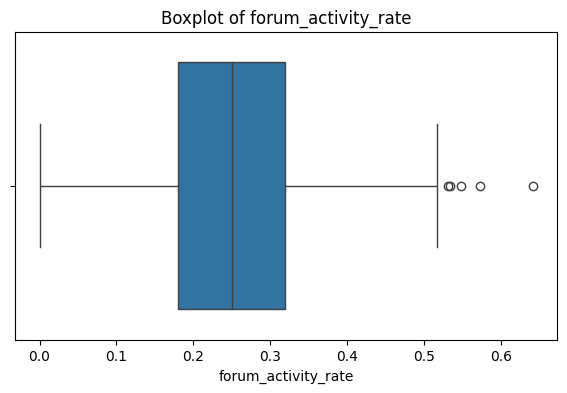

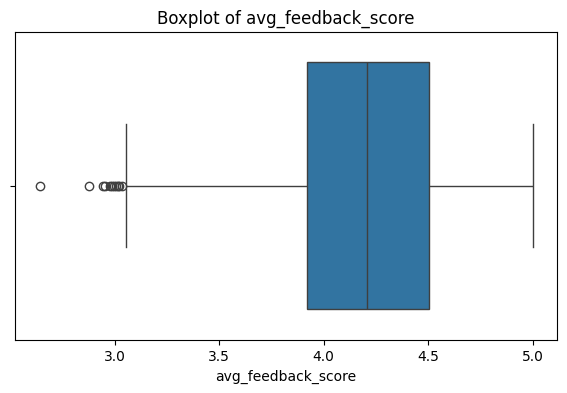

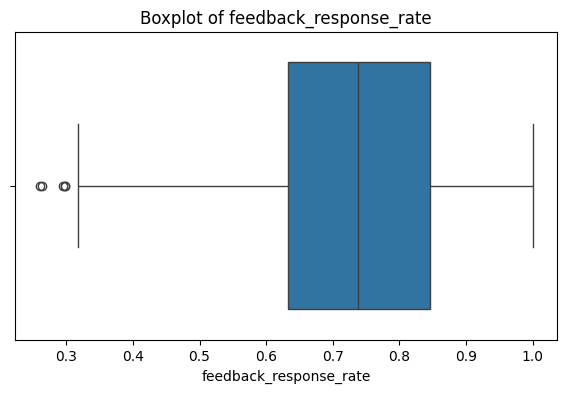

In [13]:
# BOXPLOTS FOR OUTLIER VISUALIZATION

for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

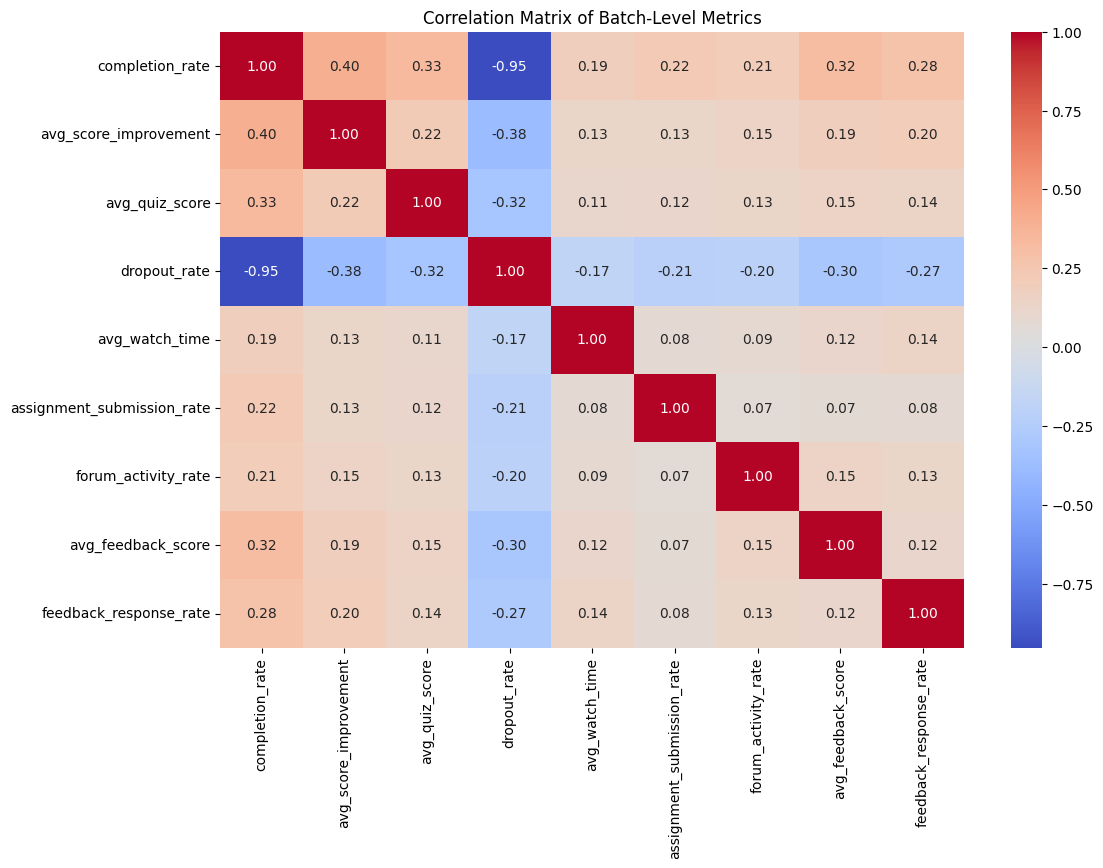

In [14]:
#CORRELATION ANALYSIS

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Batch-Level Metrics")
plt.show()

**Instructor Batch Distribution**

Because multiple rows can belong to the same instructor, we need to understand how many batches each instructor teaches.

In [15]:


batch_counts = df.groupby("instructor_id").size()

print(batch_counts.describe())

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64


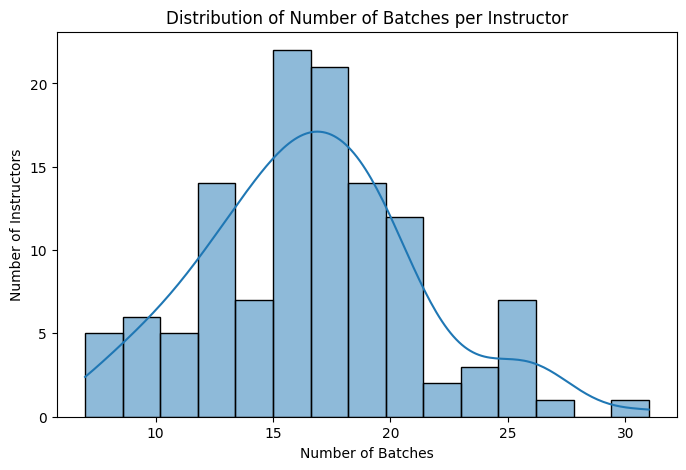

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(batch_counts, bins=15, kde=True)

plt.title("Distribution of Number of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Number of Instructors")

plt.show()

DEFINE FEATURE GROUPS

In [17]:
outcome_features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate"
]

In [18]:
engagement_features = [
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate"
]

In [19]:
feedback_features = [
    "avg_feedback_score",
    "feedback_response_rate"
]

In [20]:
#INSTRUCTOR LEVEL AGGREAGATION

instructor_data = df.groupby("instructor_id").agg(
    completion_rate=("completion_rate", "mean"),
    avg_score_improvement=("avg_score_improvement", "mean"),
    avg_quiz_score=("avg_quiz_score", "mean"),
    dropout_rate=("dropout_rate", "mean"),
    avg_watch_time=("avg_watch_time", "mean"),
    assignment_submission_rate=("assignment_submission_rate", "mean"),
    forum_activity_rate=("forum_activity_rate", "mean"),
    avg_feedback_score=("avg_feedback_score", "mean"),
    feedback_response_rate=("feedback_response_rate", "mean"),
    batch_count=("batch_id", "nunique")
).reset_index()

instructor_data.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,25
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,20
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,18
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,17
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19


In [21]:
print("Instructor-level shape:", instructor_data.shape)

Instructor-level shape: (120, 11)


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Features that should have a positive relationship with effectiveness
positive_features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

# Create a scaler
scaler = MinMaxScaler()

# Scale positive features
scaled = scaler.fit_transform(instructor_data[positive_features])

scaled_df = pd.DataFrame(
    scaled,
    columns=positive_features,
    index=instructor_data.index
)

# Scale dropout separately
dropout_scaled = scaler.fit_transform(
    instructor_data[["dropout_rate"]]
).flatten()

# Lower dropout = better, so reverse it
scaled_df["dropout_score"] = 1 - dropout_scaled


# -----------------------------
# 1. Outcome Score
# -----------------------------
scaled_df["outcome_score"] = (
    0.30 * scaled_df["completion_rate"] +
    0.25 * scaled_df["avg_score_improvement"] +
    0.20 * scaled_df["avg_quiz_score"] +
    0.25 * scaled_df["dropout_score"]
)


# -----------------------------
# 2. Engagement Score
# -----------------------------
scaled_df["engagement_score"] = (
    0.40 * scaled_df["avg_watch_time"] +
    0.35 * scaled_df["assignment_submission_rate"] +
    0.25 * scaled_df["forum_activity_rate"]
)


# -----------------------------
# 3. Feedback Score
# -----------------------------
scaled_df["feedback_score"] = (
    0.70 * scaled_df["avg_feedback_score"] +
    0.30 * scaled_df["feedback_response_rate"]
)


# -----------------------------
# 4. Overall Effectiveness
# -----------------------------
scaled_df["effectiveness_score"] = (
    0.45 * scaled_df["outcome_score"] +
    0.30 * scaled_df["engagement_score"] +
    0.25 * scaled_df["feedback_score"]
)


# Copy all scores back to instructor_data
instructor_data["outcome_score"] = scaled_df["outcome_score"]
instructor_data["engagement_score"] = scaled_df["engagement_score"]
instructor_data["feedback_score"] = scaled_df["feedback_score"]
instructor_data["effectiveness_score"] = scaled_df["effectiveness_score"]


# Create effectiveness tiers
instructor_data["effectiveness_tier"] = pd.qcut(
    instructor_data["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Scores and tiers created successfully!")

display(instructor_data.head())

Scores and tiers created successfully!


,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count,outcome_score,engagement_score,feedback_score,effectiveness_score,effectiveness_tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.428043,0.470697,0.477669,0.453246,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.686005,0.687061,0.662957,0.680560,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.705199,0.669176,0.772994,0.711341,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.288341,0.527158,0.395179,0.386696,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.856675,0.851572,0.554583,0.779621,High


In [23]:
instructor_data[
    [
        "instructor_id",
        "batch_count",
        "outcome_score",
        "engagement_score",
        "feedback_score",
        "effectiveness_score",
        "effectiveness_tier"
    ]
].sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

,instructor_id,batch_count,outcome_score,engagement_score,feedback_score,effectiveness_score,effectiveness_tier
9,I_010,13,0.997079,0.911770,0.931166,0.955008,High
36,I_037,15,0.946821,0.869885,0.883408,0.907887,High
17,I_018,14,0.878238,0.892999,0.885813,0.884560,High
104,I_105,16,0.883704,0.820668,0.839110,0.853645,High
90,I_091,8,0.893631,0.699835,0.769702,0.804510,High
117,I_118,19,0.823900,0.600578,0.976919,0.795158,High
4,I_005,19,0.856675,0.851572,0.554583,0.779621,High
24,I_025,19,0.794072,0.744714,0.734285,0.764318,High
14,I_015,17,0.718625,0.807441,0.793379,0.763958,High
50,I_051,26,0.766589,0.676030,0.773479,0.741144,High


In [24]:
#EFFECTIVENESS TIER

instructor_data["effectiveness_tier"] = pd.qcut(
    instructor_data["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)
print(
    instructor_data["effectiveness_tier"].value_counts()
)

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


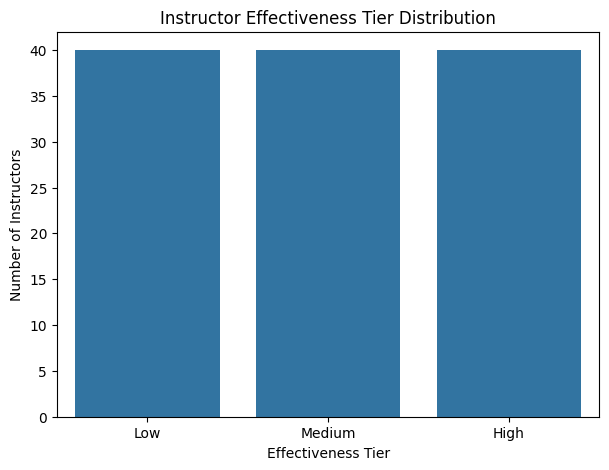

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=instructor_data,
    x="effectiveness_tier"
)

plt.title("Instructor Effectiveness Tier Distribution")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Instructors")

plt.show()

In [26]:
#INSPECT PERFORMERS

instructor_data.sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count,outcome_score,engagement_score,feedback_score,effectiveness_score,effectiveness_tier
9,I_010,0.940783,34.856747,90.656473,0.068522,0.900853,0.837532,0.343266,4.552640,0.891873,13,0.997079,0.911770,0.931166,0.955008,High
36,I_037,0.923555,34.173442,87.282865,0.086773,0.903739,0.808203,0.327316,4.532852,0.859106,15,0.946821,0.869885,0.883408,0.907887,High
17,I_018,0.867026,32.225336,89.096936,0.143953,0.882547,0.850893,0.341459,4.635637,0.781723,14,0.878238,0.892999,0.885813,0.884560,High
104,I_105,0.863880,33.871306,86.272878,0.141051,0.870686,0.823636,0.317997,4.507488,0.834154,16,0.883704,0.820668,0.839110,0.853645,High
90,I_091,0.897119,33.376943,85.028412,0.116080,0.773583,0.924766,0.264921,4.490270,0.777573,8,0.893631,0.699835,0.769702,0.804510,High
117,I_118,0.820753,32.636791,87.071798,0.202034,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.823900,0.600578,0.976919,0.795158,High
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.856675,0.851572,0.554583,0.779621,High
24,I_025,0.822837,31.296431,83.375514,0.163828,0.860510,0.791487,0.293109,4.374507,0.831763,19,0.794072,0.744714,0.734285,0.764318,High
14,I_015,0.780741,31.364753,79.832706,0.238809,0.867078,0.855627,0.285056,4.521249,0.777381,17,0.718625,0.807441,0.793379,0.763958,High
50,I_051,0.793270,31.353379,84.137118,0.210509,0.796738,0.823331,0.296151,4.479606,0.789660,26,0.766589,0.676030,0.773479,0.741144,High


In [27]:
#PREPARE ML DATASET

model_features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

X = instructor_data[model_features]

y = instructor_data["effectiveness_tier"]

In [28]:
#TRAIN/TEST SPILT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 90
Testing samples: 30


In [29]:
#SCALE FEATURES FOR LOGISTIC REGRESSION

standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

In [30]:
#LOGISTIC REGRESSION MODEL

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [31]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [32]:
#EVALUATING LOGISTIC REGRESSION

accuracy = accuracy_score(y_test, y_pred_logistic)

precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Logistic Regression
-------------------
Accuracy : 0.867
Precision: 0.88
Recall   : 0.867
F1 Score : 0.869


In [33]:
#CLASSIFICATION REPORT

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

        High       0.89      0.80      0.84        10
         Low       1.00      0.90      0.95        10
      Medium       0.75      0.90      0.82        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



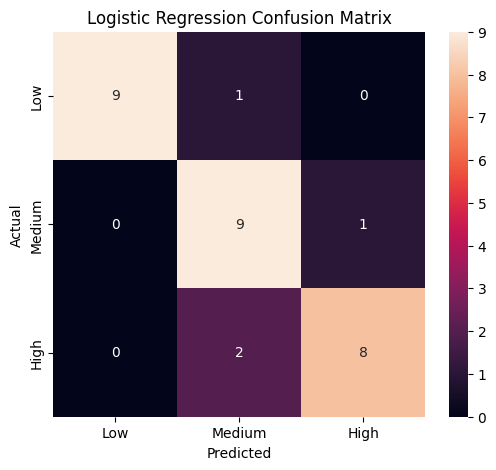

In [34]:
#CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
#RANDOM FOREST MODEL

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

In [36]:
#EVALUATING RANDOM FOREST MODEL

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1 Score :", round(rf_f1, 3))

Random Forest
-------------
Accuracy : 0.867
Precision: 0.883
Recall   : 0.867
F1 Score : 0.869


In [37]:
#COMPARING MODELS

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.866667,0.879630,0.866667,0.869219
1,Random Forest,0.866667,0.883333,0.866667,0.869024


In [38]:
#FEATURE IMPORTANCE IN RANDOM FOREST MODEL

feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,completion_rate,0.243096
3,dropout_rate,0.214852
8,feedback_response_rate,0.186965
1,avg_score_improvement,0.128597
7,avg_feedback_score,0.079864
2,avg_quiz_score,0.056015
4,avg_watch_time,0.039992
6,forum_activity_rate,0.037063
5,assignment_submission_rate,0.013557


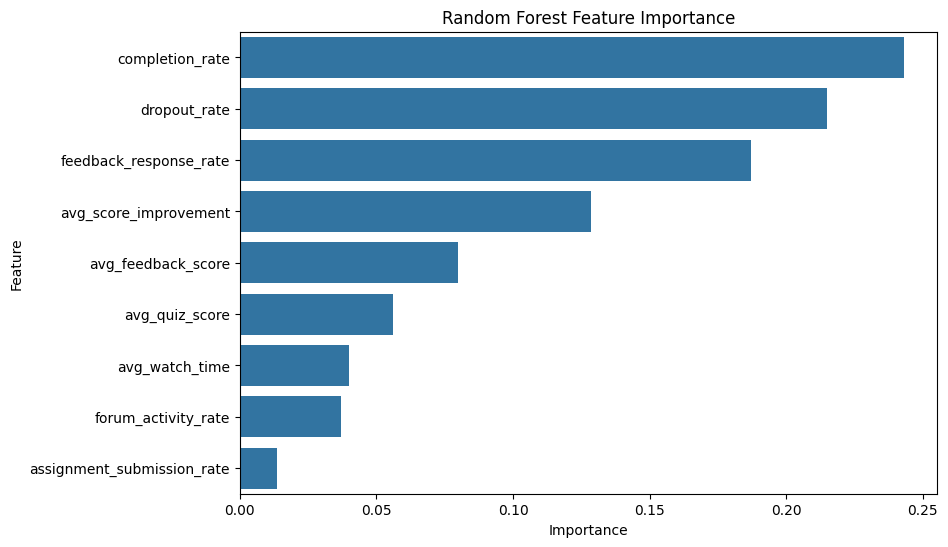

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

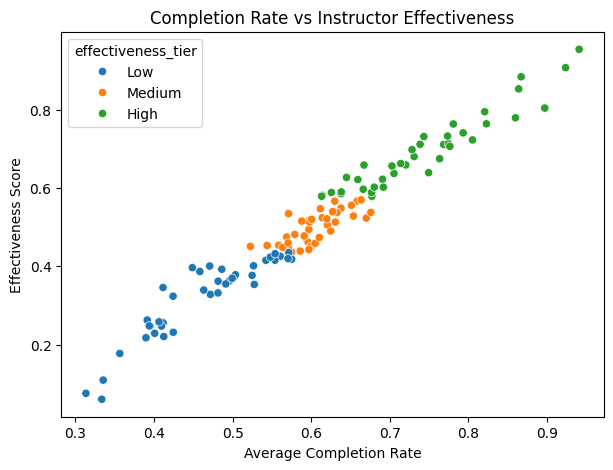

In [40]:
#ANALYSE INSTRUCTOR LEVEL RELATIONSHIPS
    #Effectiveness vs completion

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=instructor_data,
    x="completion_rate",
    y="effectiveness_score",
    hue="effectiveness_tier"
)

plt.title("Completion Rate vs Instructor Effectiveness")
plt.xlabel("Average Completion Rate")
plt.ylabel("Effectiveness Score")

plt.show()

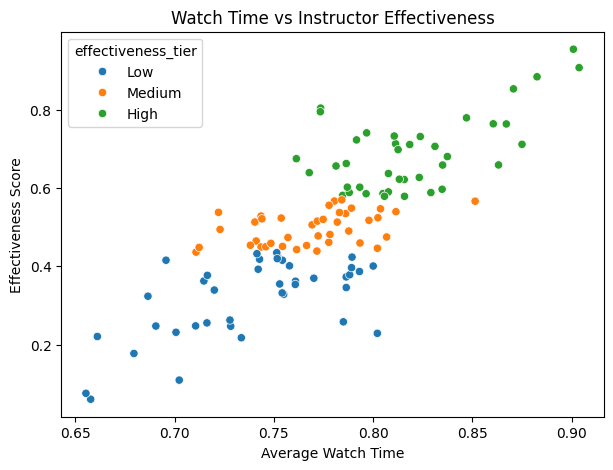

In [41]:
#Effectiveness vs engagement

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=instructor_data,
    x="avg_watch_time",
    y="effectiveness_score",
    hue="effectiveness_tier"
)

plt.title("Watch Time vs Instructor Effectiveness")
plt.xlabel("Average Watch Time")
plt.ylabel("Effectiveness Score")

plt.show()

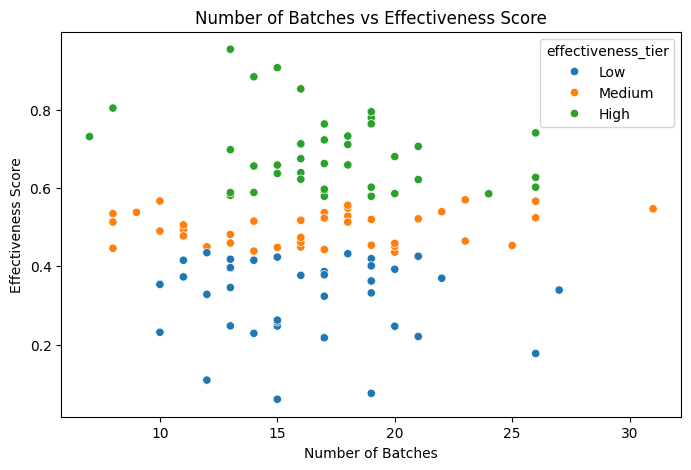

In [42]:
#Batch Count vs Effectiveness

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=instructor_data,
    x="batch_count",
    y="effectiveness_score",
    hue="effectiveness_tier"
)

plt.title("Number of Batches vs Effectiveness Score")
plt.xlabel("Number of Batches")
plt.ylabel("Effectiveness Score")

plt.show()

In [43]:
#SAVING RESULTS

instructor_data.to_csv(
    "instructor_effectiveness_results.csv",
    index=False
)

In [44]:
#TOP 10 INSTRUCTORS

top_10 = instructor_data.sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

display(
    top_10[
        [
            "instructor_id",
            "batch_count",
            "effectiveness_score",
            "effectiveness_tier"
        ]
    ]
)

,instructor_id,batch_count,effectiveness_score,effectiveness_tier
9,I_010,13,0.955008,High
36,I_037,15,0.907887,High
17,I_018,14,0.884560,High
104,I_105,16,0.853645,High
90,I_091,8,0.804510,High
117,I_118,19,0.795158,High
4,I_005,19,0.779621,High
24,I_025,19,0.764318,High
14,I_015,17,0.763958,High
50,I_051,26,0.741144,High


## 1. Which features most influenced instructor effectiveness, and why?

The most influential features were identified using the Random Forest feature importance scores.

Learner outcome metrics such as completion rate, score improvement, quiz performance, and dropout rate are important because they directly reflect whether learners successfully progressed through the course.

Engagement variables such as watch time and assignment submission rate provide additional information about learner participation.

Feedback variables provide a learner-perception perspective and complement the objective outcome metrics.

Feature importance should be interpreted as association rather than proof of causation.

## 2. Which variables could be misleading or confounded?

Some variables may be influenced by factors other than instructor effectiveness.

For example, completion rate and dropout rate can depend on course difficulty, learner motivation, learner background, or external circumstances.

Quiz scores and score improvement may also depend on the difficulty of the assessment and the learners' starting level.

Engagement metrics such as watch time and forum activity can vary depending on course design and the type of subject being taught.

Feedback scores may also be influenced by learner expectations, course difficulty, or response bias.

Therefore, these variables should not automatically be interpreted as direct measures of instructor quality.

## 3. How could this model fail in real-world usage?

A major limitation is that the effectiveness tiers are constructed from the same
metrics used as model inputs. Therefore, the model is primarily learning to reproduce
the scoring rule rather than independently predicting future instructor performance.

The model may also fail when applied to new courses, different learner populations,
or courses with different levels of difficulty.

For example, a difficult course may naturally have lower completion and quiz scores
even when the instructor is effective.

The dataset also contains batch-level aggregate statistics rather than individual
learner-level data, which limits the ability to account for differences between
learners.

Therefore, the current model should be viewed as an exploratory classification model
rather than a validated system for predicting future instructor performance.

## 4. What additional data would you want to improve this analysis?

Additional useful information could include:

- Course difficulty
- Number of learners in each batch
- Learner pre-assessment scores
- Learner experience level
- Course duration
- Instructor experience
- Instructor workload
- Attendance information
- Assignment difficulty
- Learner-level outcomes
- Qualitative learner feedback
- Historical instructor performance

These variables could help separate instructor effects from course and learner effects.

## 5. Should this model be used for instructor performance evaluation? Why or why not?

The model should not be used as the sole method for evaluating instructor performance.

It can be useful as a decision-support tool for identifying patterns and instructors who may benefit from further review or support.

However, automated rankings could be unfair if differences in course difficulty, learner populations, or batch characteristics are not considered.

Human review and additional contextual information should therefore be included before making important decisions about instructors.

## Conclusion

This analysis developed an instructor effectiveness framework using learner outcomes, engagement, and feedback metrics.

Batch-level observations were aggregated to the instructor level because each instructor can teach multiple batches.

An effectiveness score was constructed by combining outcome, engagement, and feedback components. The score was then divided into Low, Medium, and High effectiveness tiers.

Two classical machine learning approaches, Logistic Regression and Random Forest, were evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The results provide a way to identify patterns associated with instructor effectiveness. However, the model should be treated as a decision-support tool rather than a standalone performance evaluation system.

The main limitations are potential confounding factors, the relatively small instructor-level sample size, and the fact that the effectiveness tiers are constructed from the same metrics used by the model.